In [1]:
# !pip install wfdb  # uncomment if not already installed

import wfdb
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
## Data loading — European ST-T Database

pn_dir = 'edb'

record_name = 'e0103'  # start with the one you already explored

sig, fields = wfdb.rdsamp(record_name, pn_dir=pn_dir)
ann = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)

print(fields['sig_name'])
print(fields['fs'])
print(sig.shape)
print(Counter(ann.symbol))

['V4', 'MLIII']
250
(1800000, 2)
Counter({'N': 7212, 'V': 82, '+': 17, 's': 15, '~': 8, 'F': 2})


In [3]:
for s, sym, aux in zip(ann.sample, ann.symbol, ann.aux_note):
    if aux and ('ST' in aux or 'T' in aux[:3]):
        print(s, repr(sym), aux)

214719 's' (ST1+ 
244876 's' AST1+200
255059 's' ST1+) 
397333 's' (ST1+ 
424482 's' AST1+150
435369 's' ST1+) 
472933 '+' (VT
575587 's' (ST1+ 
601684 's' AST1+150
613796 's' ST1+) 
727684 's' (ST1+ 
748347 's' AST1+200
759225 's' ST1+) 
1625833 '+' (VT
1702273 's' (ST1+ 
1730021 's' AST1+100
1739121 's' ST1+) 


In [4]:
for sample, sym, aux in zip(ann.sample, ann.symbol, ann.aux_note):
    if sym == 's':
        print(repr(sample), repr(sym), repr(aux))

np.int64(214719) 's' '(ST1+\x00'
np.int64(244876) 's' 'AST1+200'
np.int64(255059) 's' 'ST1+)\x00'
np.int64(397333) 's' '(ST1+\x00'
np.int64(424482) 's' 'AST1+150'
np.int64(435369) 's' 'ST1+)\x00'
np.int64(575587) 's' '(ST1+\x00'
np.int64(601684) 's' 'AST1+150'
np.int64(613796) 's' 'ST1+)\x00'
np.int64(727684) 's' '(ST1+\x00'
np.int64(748347) 's' 'AST1+200'
np.int64(759225) 's' 'ST1+)\x00'
np.int64(1702273) 's' '(ST1+\x00'
np.int64(1730021) 's' 'AST1+100'
np.int64(1739121) 's' 'ST1+)\x00'


In [5]:
def parse_st_episodes(ann):
    """Return list of dicts: {lead, sign, onset, peak, offset, magnitude_uV}"""
    episodes = []
    open_ep = {}

    for sample, sym, aux in zip(ann.sample, ann.symbol, ann.aux_note):
        if sym != 's' or not aux:
            continue

        aux = aux.rstrip('\x00')

        if aux.startswith('(ST') or aux.startswith('(T'):
            key = aux[1:].rstrip('+-')
            sign = '+' if aux.endswith('+') else '-'
            open_ep[key] = {'lead': key, 'sign': sign, 'onset': sample}

        elif aux.startswith('A'):
            key = aux[1:].split('+')[0].split('-')[0]
            if key in open_ep:
                after_sign = aux.split('+')[-1] if '+' in aux else aux.split('-')[-1]
                mag = int(after_sign)
                open_ep[key]['peak'] = sample
                open_ep[key]['magnitude_uV'] = mag

        elif aux.endswith(')'):
            key = aux.rstrip('+-)')
            if key in open_ep:
                open_ep[key]['offset'] = sample
                episodes.append(open_ep.pop(key))

    return episodes

episodes = parse_st_episodes(ann)
for e in episodes:
    print(e)


{'lead': 'ST1', 'sign': '+', 'onset': np.int64(214719), 'peak': np.int64(244876), 'magnitude_uV': 200, 'offset': np.int64(255059)}
{'lead': 'ST1', 'sign': '+', 'onset': np.int64(397333), 'peak': np.int64(424482), 'magnitude_uV': 150, 'offset': np.int64(435369)}
{'lead': 'ST1', 'sign': '+', 'onset': np.int64(575587), 'peak': np.int64(601684), 'magnitude_uV': 150, 'offset': np.int64(613796)}
{'lead': 'ST1', 'sign': '+', 'onset': np.int64(727684), 'peak': np.int64(748347), 'magnitude_uV': 200, 'offset': np.int64(759225)}
{'lead': 'ST1', 'sign': '+', 'onset': np.int64(1702273), 'peak': np.int64(1730021), 'magnitude_uV': 100, 'offset': np.int64(1739121)}


In [6]:
## Full record list

edb_records = wfdb.io.get_record_list('edb')
print(len(edb_records))
print(edb_records)

90
['e0103', 'e0104', 'e0105', 'e0106', 'e0107', 'e0108', 'e0110', 'e0111', 'e0112', 'e0113', 'e0114', 'e0115', 'e0116', 'e0118', 'e0119', 'e0121', 'e0122', 'e0123', 'e0124', 'e0125', 'e0126', 'e0127', 'e0129', 'e0133', 'e0136', 'e0139', 'e0147', 'e0148', 'e0151', 'e0154', 'e0155', 'e0159', 'e0161', 'e0162', 'e0163', 'e0166', 'e0170', 'e0202', 'e0203', 'e0204', 'e0205', 'e0206', 'e0207', 'e0208', 'e0210', 'e0211', 'e0212', 'e0213', 'e0302', 'e0303', 'e0304', 'e0305', 'e0306', 'e0403', 'e0404', 'e0405', 'e0406', 'e0408', 'e0409', 'e0410', 'e0411', 'e0413', 'e0415', 'e0417', 'e0418', 'e0501', 'e0509', 'e0515', 'e0601', 'e0602', 'e0603', 'e0604', 'e0605', 'e0606', 'e0607', 'e0609', 'e0610', 'e0611', 'e0612', 'e0613', 'e0614', 'e0615', 'e0704', 'e0801', 'e0808', 'e0817', 'e0818', 'e1301', 'e1302', 'e1304']


In [7]:
## Batch episode extraction across all EDB records (with retry + delay)

import time

all_episodes = []

for rec in edb_records:
    ann = None
    for attempt in range(3):  # try up to 3 times
        try:
            ann = wfdb.rdann(rec, 'atr', pn_dir='edb')
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2)  # brief pause before retrying
            else:
                print(f"Skipping {rec} after 3 attempts: {e}")

    if ann is None:
        continue

    eps = parse_st_episodes(ann)
    for e in eps:
        e['record'] = rec
        all_episodes.append(e)

    time.sleep(0.2)  # small delay between records to avoid hammering the server

print(f"Total ST episodes found: {len(all_episodes)}")

Total ST episodes found: 364


In [8]:
from collections import Counter
lead_counts = Counter(e['lead'] for e in all_episodes)
print(lead_counts)

Counter({'ST0': 183, 'ST1': 181})


In [9]:
## Rebuild: extract_windows with per-record baseline normalization

WINDOW_SEC = 4
FS = 250
WINDOW_SIZE = WINDOW_SEC * FS
BUFFER = FS * 30

def extract_windows(record_name, episodes_for_record, pn_dir='edb', lead_idx=0):
    sig = None
    for attempt in range(3):
        try:
            sig, fields = wfdb.rdsamp(record_name, pn_dir=pn_dir)
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2)
            else:
                raise

    n_samples = sig.shape[0]
    signal = sig[:, lead_idx]

    baseline = np.median(signal)
    signal = signal - baseline

    pos_windows = []
    neg_windows = []

    for ep in episodes_for_record:
        onset, offset = ep['onset'], ep['offset']
        span = offset - onset
        if span < WINDOW_SIZE:
            continue
        n_win = max(1, span // WINDOW_SIZE)
        for i in range(n_win):
            start = onset + i * WINDOW_SIZE
            end = start + WINDOW_SIZE
            if end <= offset:
                pos_windows.append(signal[start:end])

    exclusion = [(ep['onset'] - BUFFER, ep['offset'] + BUFFER) for ep in episodes_for_record]
    attempts = 0
    while len(neg_windows) < len(pos_windows) and attempts < 500:
        start = random.randint(0, n_samples - WINDOW_SIZE)
        end = start + WINDOW_SIZE
        if not any(s < end and start < e for s, e in exclusion):
            neg_windows.append(signal[start:end])
        attempts += 1

    return pos_windows, neg_windows

In [10]:
## Rebuild: windows tagged individually with record + label (normalized)

records_data = []

for rec in edb_records:
    eps = [e for e in all_episodes if e['record'] == rec]
    if not eps:
        continue
    try:
        pos, neg = extract_windows(rec, eps)
    except Exception as ex:
        print(f"Skipping {rec}: {ex}")
        continue

    for w in pos:
        records_data.append({'signal': w, 'label': 1, 'record': rec})
    for w in neg:
        records_data.append({'signal': w, 'label': 0, 'record': rec})

print(f"Total tagged windows: {len(records_data)}")

Total tagged windows: 52615


In [11]:
## Subject-grouped train/test split

from sklearn.model_selection import train_test_split
SEED = 42
same_subject_groups = [
    ['e0118', 'e0119', 'e0121', 'e0122'],
    ['e0123', 'e0124', 'e0125', 'e0126'],
    ['e0129', 'e0133'],
    ['e0136', 'e0139'],
    ['e0147', 'e0148'],
    ['e0154', 'e0155'],
    ['e0162', 'e0163'],
]

# Map every record to a subject ID (grouped records share one ID; others are their own subject)
record_to_subject = {}
for group in same_subject_groups:
    subj_id = group[0]  # use first record name as the group's subject ID
    for rec in group:
        record_to_subject[rec] = subj_id

records_with_episodes = sorted(set(d['record'] for d in records_data))
for rec in records_with_episodes:
    if rec not in record_to_subject:
        record_to_subject[rec] = rec  # standalone subject

subjects = sorted(set(record_to_subject[rec] for rec in records_with_episodes))
print(f"Records with episodes: {len(records_with_episodes)}")
print(f"Unique subjects: {len(subjects)}")

train_subjects, test_subjects = train_test_split(subjects, test_size=0.2, random_state=SEED)

train_records = [rec for rec in records_with_episodes if record_to_subject[rec] in train_subjects]
test_records = [rec for rec in records_with_episodes if record_to_subject[rec] in test_subjects]

print(f"Train records: {len(train_records)}, Test records: {len(test_records)}")

Records with episodes: 85
Unique subjects: 76
Train records: 68, Test records: 17


In [12]:
## Check baseline signal levels across records

sample_records = train_records[:5] + test_records[:5]

for rec in sample_records:
    windows = [d['signal'] for d in records_data if d['record'] == rec and d['label'] == 0]
    if not windows:
        continue
    all_vals = np.concatenate(windows)
    print(f"{rec}: mean={all_vals.mean():.4f}, median={np.median(all_vals):.4f}, std={all_vals.std():.4f}")

e0104: mean=0.0044, median=0.0000, std=0.1390
e0105: mean=0.0601, median=0.0150, std=0.1390
e0106: mean=-0.0207, median=-0.0050, std=0.1483
e0108: mean=0.0901, median=0.0150, std=0.3031
e0110: mean=0.0132, median=-0.0050, std=0.1536
e0103: mean=0.0729, median=0.0000, std=0.2919
e0107: mean=-0.0747, median=0.0050, std=0.2765
e0114: mean=-0.0145, median=0.0000, std=0.1217
e0116: mean=0.0445, median=-0.0100, std=0.2641
e0147: mean=0.0216, median=0.0050, std=0.1271


In [13]:
## Assemble X_train / y_train / X_test / y_test

train_set = [d for d in records_data if d['record'] in train_records]
test_set = [d for d in records_data if d['record'] in test_records]

X_train = np.array([d['signal'] for d in train_set])
y_train = np.array([d['label'] for d in train_set])
X_test = np.array([d['signal'] for d in test_set])
y_test = np.array([d['label'] for d in test_set])

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Train label balance: {Counter(y_train)}")
print(f"Test label balance: {Counter(y_test)}")

X_train: (42162, 1000), y_train: (42162,)
X_test: (10453, 1000), y_test: (10453,)
Train label balance: Counter({np.int64(1): 26112, np.int64(0): 16050})
Test label balance: Counter({np.int64(1): 6528, np.int64(0): 3925})


In [14]:
## Reshape for Keras + class weights

X_train_r = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test_r = X_test.reshape(-1, WINDOW_SIZE, 1)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_arr))

print(X_train_r.shape, X_test_r.shape)
print(class_weights)

(42162, 1000, 1) (10453, 1000, 1)
{0: np.float64(1.3134579439252336), 1: np.float64(0.8073299632352942)}


In [15]:
## CNN model (baseline)

def build_cnn(input_shape):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

cnn_model = build_cnn((WINDOW_SIZE, 1))
cnn_model.summary()

C:\Users\owner\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 994, 32)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 497, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 493, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 246, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 244, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,585 (170.25 KB)

 Trainable params: 43,585 (170.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
## Fresh model, normalized data
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)

cnn_model = build_cnn((WINDOW_SIZE, 1))

history = cnn_model.fit(
    X_train_r, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.6895 - auc: 0.7449 - loss: 0.6055 - val_accuracy: 0.7826 - val_auc: 0.8615 - val_loss: 0.4553
Epoch 2/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 45s 80ms/step - accuracy: 0.7164 - auc: 0.7859 - loss: 0.5619 - val_accuracy: 0.7839 - val_auc: 0.8480 - val_loss: 0.4479
Epoch 3/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 47s 84ms/step - accuracy: 0.7319 - auc: 0.8106 - loss: 0.5319 - val_accuracy: 0.7142 - val_auc: 0.8001 - val_loss: 0.5033
Epoch 4/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 47s 83ms/step - accuracy: 0.7449 - auc: 0.8295 - loss: 0.5073 - val_accuracy: 0.7388 - val_auc: 0.8335 - val_loss: 0.4813
Epoch 5/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 46s 82ms/step - accuracy: 0.7515 - auc: 0.8406 - loss: 0.4920 - val_accuracy: 0.7505 - val_auc: 0.8314 - val_loss: 0.4754
Epoch 6/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 46s 82ms/step - accuracy: 0.7652 - auc: 0.8545 - loss: 0.4723 - val_accuracy: 0.7537 - val_auc: 0.8120 - val_loss: 0.4989


In [17]:
## Evaluate normalized-data model on held-out test set

y_pred_prob = cnn_model.predict(X_test_r).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Baseline (0)', 'Ischemic (1)']))

cm = confusion_matrix(y_test, y_pred)
print(cm)

327/327 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
              precision    recall  f1-score   support

Baseline (0)       0.53      0.59      0.56      3925
Ischemic (1)       0.74      0.69      0.71      6528

    accuracy                           0.65     10453
   macro avg       0.63      0.64      0.64     10453
weighted avg       0.66      0.65      0.65     10453

[[2327 1598]
 [2044 4484]]


In [18]:
## Transformer model (baseline)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_transformer(input_shape, head_size=32, num_heads=4, ff_dim=64, num_blocks=2, dropout=0.2):
    inputs = layers.Input(shape=input_shape)

    # Downsample raw signal first — 1000 raw samples is too long for attention to be efficient/effective
    x = layers.Conv1D(32, kernel_size=7, strides=4, activation='relu')(inputs)
    x = layers.Conv1D(64, kernel_size=5, strides=4, activation='relu')(x)

    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

transformer_model = build_transformer((WINDOW_SIZE, 1))
transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 1000, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_6 (Conv1D)             │ (None, 249, 32)           │             256 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_7 (Conv1D)             │ (None, 62, 64)            │          10,304 │ conv1d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 62, 64)            │             128 │ conv1d_7[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 62, 64)            │          33,216 │ layer_normalization[0][0], │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 62, 64)            │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 62, 64)            │               0 │ dropout_3[0][0],           │
│                               │                           │                 │ conv1d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 62, 64)            │             128 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_8 (Conv1D)             │ (None, 62, 64)            │           4,160 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 62, 64)            │               0 │ conv1d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_9 (Conv1D)             │ (None, 62, 64)            │           4,160 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 62, 64)            │               0 │ conv1d_9[0][0], add[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 62, 64)            │             128 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 62, 64)            │          33,216 │ layer_normalization_2[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 98,369 (384.25 KB)

 Trainable params: 98,369 (384.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
## Train transformer

transformer_history = transformer_model.fit(
    X_train_r, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - accuracy: 0.7101 - auc: 0.7857 - loss: 0.5628 - val_accuracy: 0.8019 - val_auc: 0.8483 - val_loss: 0.4637
Epoch 2/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - accuracy: 0.7707 - auc: 0.8592 - loss: 0.4664 - val_accuracy: 0.7551 - val_auc: 0.7716 - val_loss: 0.5558
Epoch 3/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 91s 162ms/step - accuracy: 0.8015 - auc: 0.8905 - loss: 0.4155 - val_accuracy: 0.7654 - val_auc: 0.8087 - val_loss: 0.5720
Epoch 4/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 103s 184ms/step - accuracy: 0.8186 - auc: 0.9066 - loss: 0.3858 - val_accuracy: 0.7870 - val_auc: 0.8740 - val_loss: 0.4583
Epoch 5/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 236s 351ms/step - accuracy: 0.8347 - auc: 0.9199 - loss: 0.3587 - val_accuracy: 0.7606 - val_auc: 0.8244 - val_loss: 0.5945
Epoch 6/30
560/560 ━━━━━━━━━━━━━━━━━━━━ 208s 372ms/step - accuracy: 0.8470 - auc: 0.9288 - loss: 0.3394 - val_accuracy: 0.7464 - val_auc: 0.8278 - val_loss: 0.6292
Epoch 7/30
560/560 

In [20]:
## Evaluate transformer on held-out test set

y_pred_prob_t = transformer_model.predict(X_test_r).ravel()
y_pred_t = (y_pred_prob_t >= 0.5).astype(int)

print(classification_report(y_test, y_pred_t, target_names=['Baseline (0)', 'Ischemic (1)']))

cm_t = confusion_matrix(y_test, y_pred_t)
print(cm_t)

327/327 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step
              precision    recall  f1-score   support

Baseline (0)       0.53      0.80      0.64      3925
Ischemic (1)       0.83      0.57      0.68      6528

    accuracy                           0.66     10453
   macro avg       0.68      0.69      0.66     10453
weighted avg       0.72      0.66      0.66     10453

[[3137  788]
 [2777 3751]]


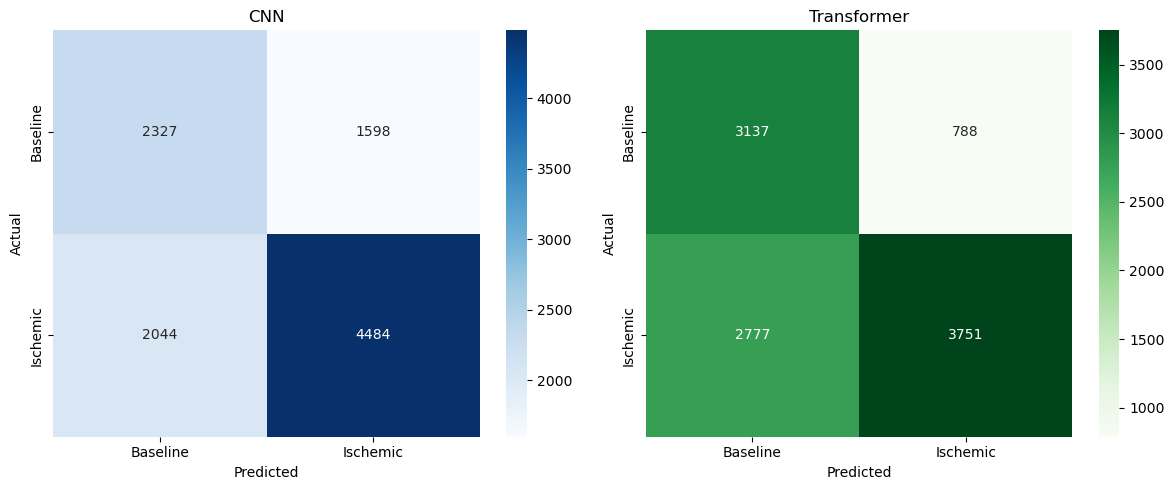

In [21]:
## Side-by-side confusion matrix comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baseline', 'Ischemic'], yticklabels=['Baseline', 'Ischemic'])
axes[0].set_title('CNN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_t, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Baseline', 'Ischemic'], yticklabels=['Baseline', 'Ischemic'])
axes[1].set_title('Transformer')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

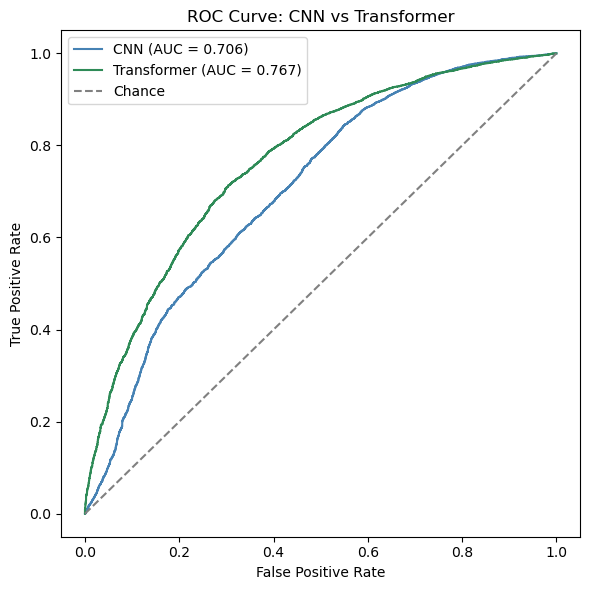

In [22]:
## ROC curve comparison

from sklearn.metrics import roc_curve, auc

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_prob)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_prob_t)
roc_auc_t = auc(fpr_t, tpr_t)

plt.figure(figsize=(6, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {roc_auc_cnn:.3f})', color='steelblue')
plt.plot(fpr_t, tpr_t, label=f'Transformer (AUC = {roc_auc_t:.3f})', color='seagreen')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: CNN vs Transformer')
plt.legend()
plt.tight_layout()
plt.show()

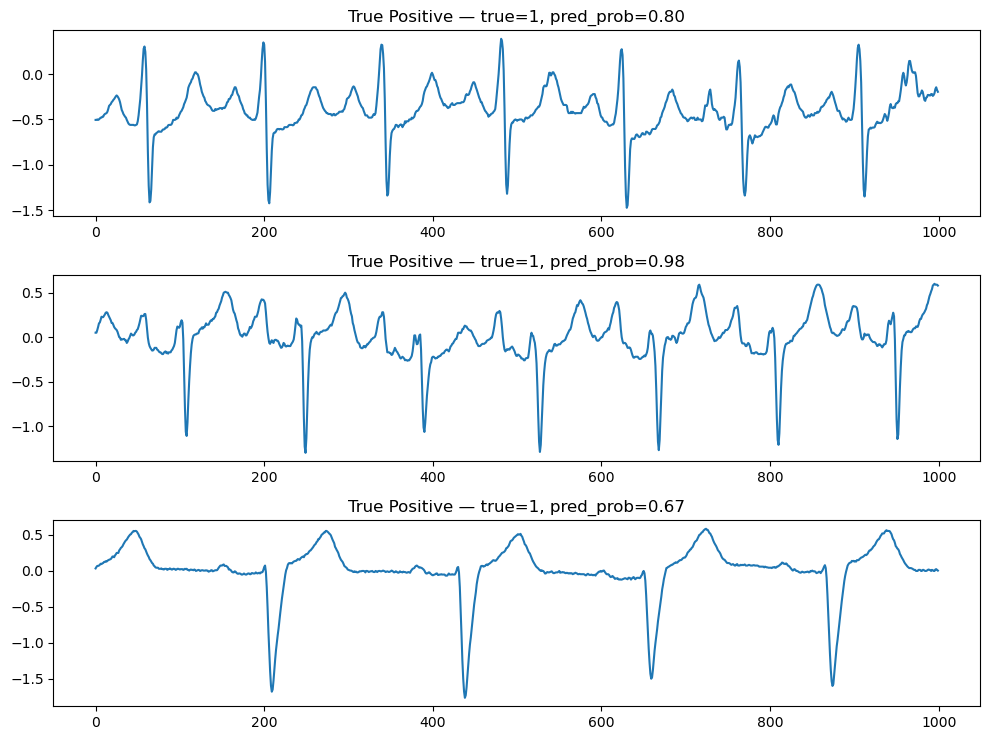

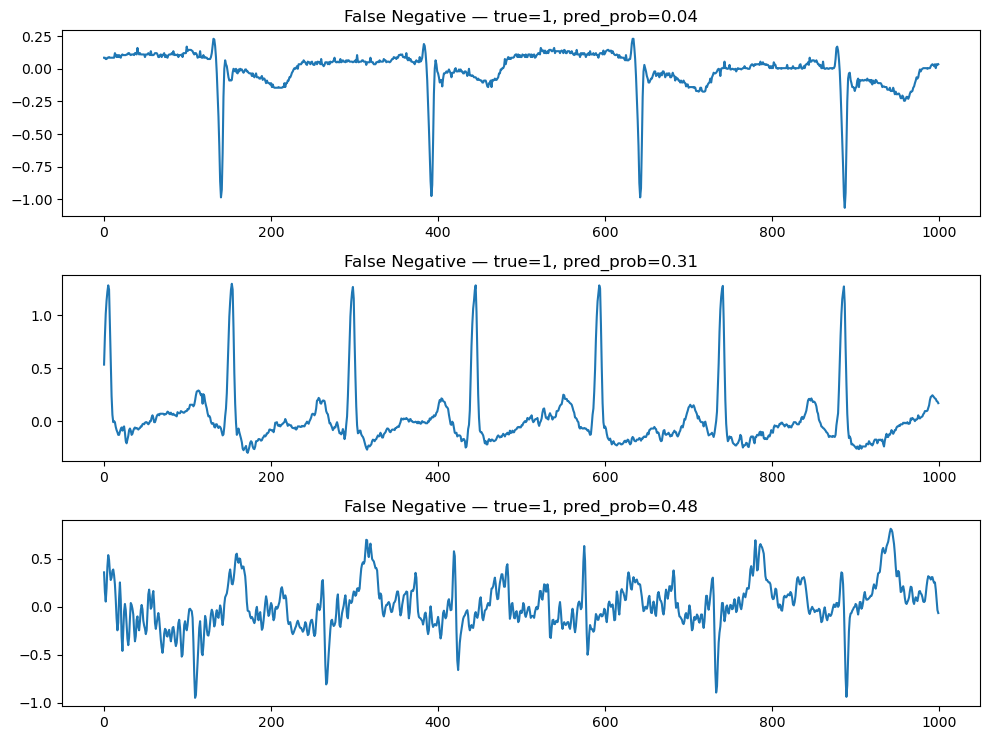

In [23]:
## Example waveform visualizations

def plot_examples(X, y_true, y_pred_prob, n=3, title_prefix=""):
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.5*n))
    if n == 1:
        axes = [axes]
    for i, idx in enumerate(np.random.choice(len(X), n, replace=False)):
        axes[i].plot(X[idx].flatten())
        axes[i].set_title(f"{title_prefix} — true={y_true[idx]}, pred_prob={y_pred_prob[idx]:.2f}")
    plt.tight_layout()
    plt.show()

# True positives: model correctly caught ischemia
tp_mask = (y_test == 1) & (y_pred_prob_t >= 0.5)
tp_idx = np.where(tp_mask)[0]
plot_examples(X_test_r[tp_idx], y_test[tp_idx], y_pred_prob_t[tp_idx], n=3, title_prefix="True Positive")

# False negatives: model missed real ischemia
fn_mask = (y_test == 1) & (y_pred_prob_t < 0.5)
fn_idx = np.where(fn_mask)[0]
plot_examples(X_test_r[fn_idx], y_test[fn_idx], y_pred_prob_t[fn_idx], n=3, title_prefix="False Negative")

In [24]:
## Quick quantitative check: what distinguishes these specific windows?

def window_stats(window):
    w = window.flatten()
    return {
        'amplitude_range': w.max() - w.min(),
        'std': w.std(),
        'mean_abs_diff': np.mean(np.abs(np.diff(w)))  # rough noise/high-freq measure
    }

print("--- True Positives ---")
for idx in tp_idx[:3]:
    print(window_stats(X_test_r[idx]))

print("--- False Negatives ---")
for idx in fn_idx[:3]:
    print(window_stats(X_test_r[idx]))

--- True Positives ---
{'amplitude_range': np.float64(1.2800000000000002), 'std': np.float64(0.16265607889039993), 'mean_abs_diff': np.float64(0.03069069069069071)}
{'amplitude_range': np.float64(1.58), 'std': np.float64(0.15644606986115056), 'mean_abs_diff': np.float64(0.030135135135135153)}
{'amplitude_range': np.float64(1.3500000000000005), 'std': np.float64(0.14171392874379005), 'mean_abs_diff': np.float64(0.03091091091091092)}
--- False Negatives ---
{'amplitude_range': np.float64(2.07), 'std': np.float64(0.2596767450119475), 'mean_abs_diff': np.float64(0.02296796796796797)}
{'amplitude_range': np.float64(2.005), 'std': np.float64(0.2564973742068328), 'mean_abs_diff': np.float64(0.023113113113113117)}
{'amplitude_range': np.float64(2.0599999999999996), 'std': np.float64(0.2595595303104858), 'mean_abs_diff': np.float64(0.02356856856856857)}


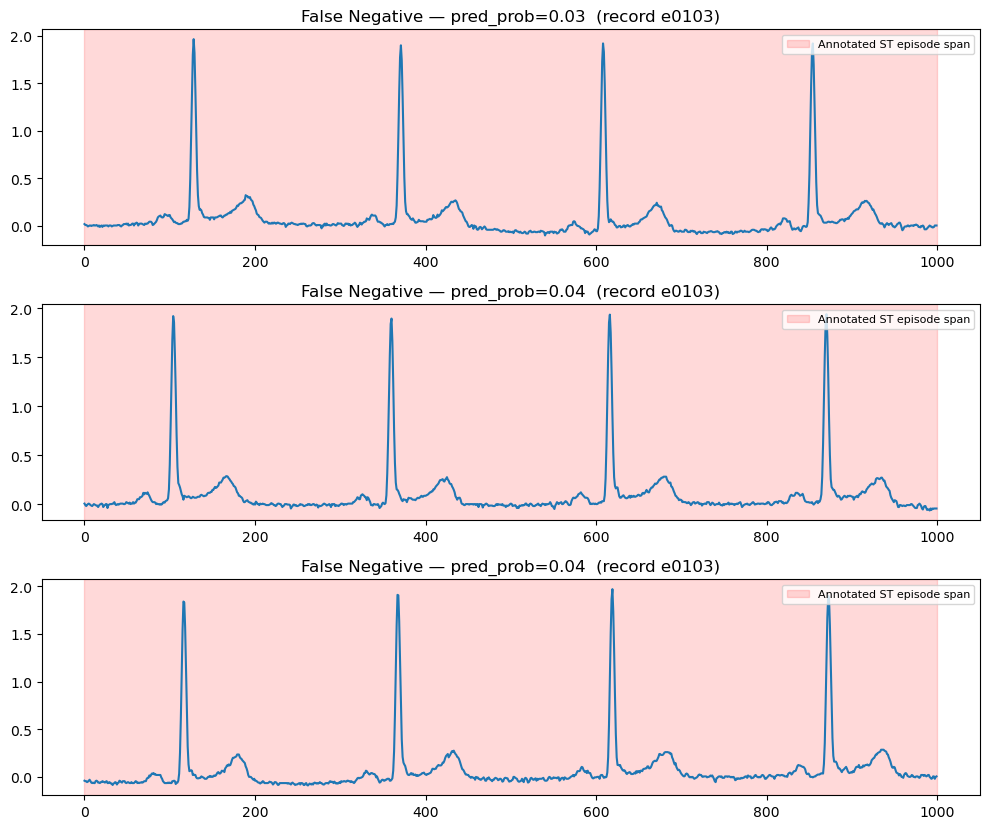

In [26]:
## Overlay ST episode onset/peak/offset markers on false-negative windows

def extract_positive_windows_with_meta(record_name, episodes_for_record, pn_dir='edb', lead_idx=0):
    sig = None
    for attempt in range(3):
        try:
            sig, fields = wfdb.rdsamp(record_name, pn_dir=pn_dir)
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2)
            else:
                raise

    signal = sig[:, lead_idx]
    baseline = np.median(signal)
    signal = signal - baseline

    meta_windows = []
    for ep in episodes_for_record:
        onset, offset = ep['onset'], ep['offset']
        peak = ep.get('peak', None)
        span = offset - onset
        if span < WINDOW_SIZE:
            continue
        n_win = max(1, span // WINDOW_SIZE)
        for i in range(n_win):
            start = onset + i * WINDOW_SIZE
            end = start + WINDOW_SIZE
            if end <= offset:
                meta_windows.append({
                    'signal': signal[start:end],
                    'record': record_name,
                    'win_start': start,
                    'onset': onset,
                    'peak': peak,
                    'offset': offset,
                })
    return meta_windows

# Rebuild positive windows with metadata for every test record
test_pos_meta = []
for rec in test_records:
    eps = [e for e in all_episodes if e['record'] == rec]
    if not eps:
        continue
    test_pos_meta.extend(extract_positive_windows_with_meta(rec, eps))

# Match each false-negative test window to its metadata by exact signal match
def find_meta_for_window(window, meta_list):
    w = window.flatten()
    for m in meta_list:
        if np.array_equal(w, m['signal']):
            return m
    return None

fig, axes = plt.subplots(len(fn_idx[:3]), 1, figsize=(10, 2.8 * len(fn_idx[:3])))
if len(fn_idx[:3]) == 1:
    axes = [axes]

for i, idx in enumerate(fn_idx[:3]):
    window = X_test_r[idx].flatten()
    meta = find_meta_for_window(window, test_pos_meta)

    axes[i].plot(window)
    title = f"False Negative — pred_prob={y_pred_prob_t[idx]:.2f}"

    if meta is not None:
        onset_x = meta['onset'] - meta['win_start']
        offset_x = meta['offset'] - meta['win_start']
        axes[i].axvspan(max(onset_x, 0), min(offset_x, len(window)), color='red', alpha=0.15, label='Annotated ST episode span')
        if meta['peak'] is not None:
            peak_x = meta['peak'] - meta['win_start']
            if 0 <= peak_x <= len(window):
                axes[i].axvline(peak_x, color='darkred', linestyle='--', linewidth=1, label='Annotated peak')
        title += f"  (record {meta['record']})"
        axes[i].legend(fontsize=8, loc='upper right')
    else:
        title += "  (metadata match not found)"

    axes[i].set_title(title)

plt.tight_layout()
plt.show()

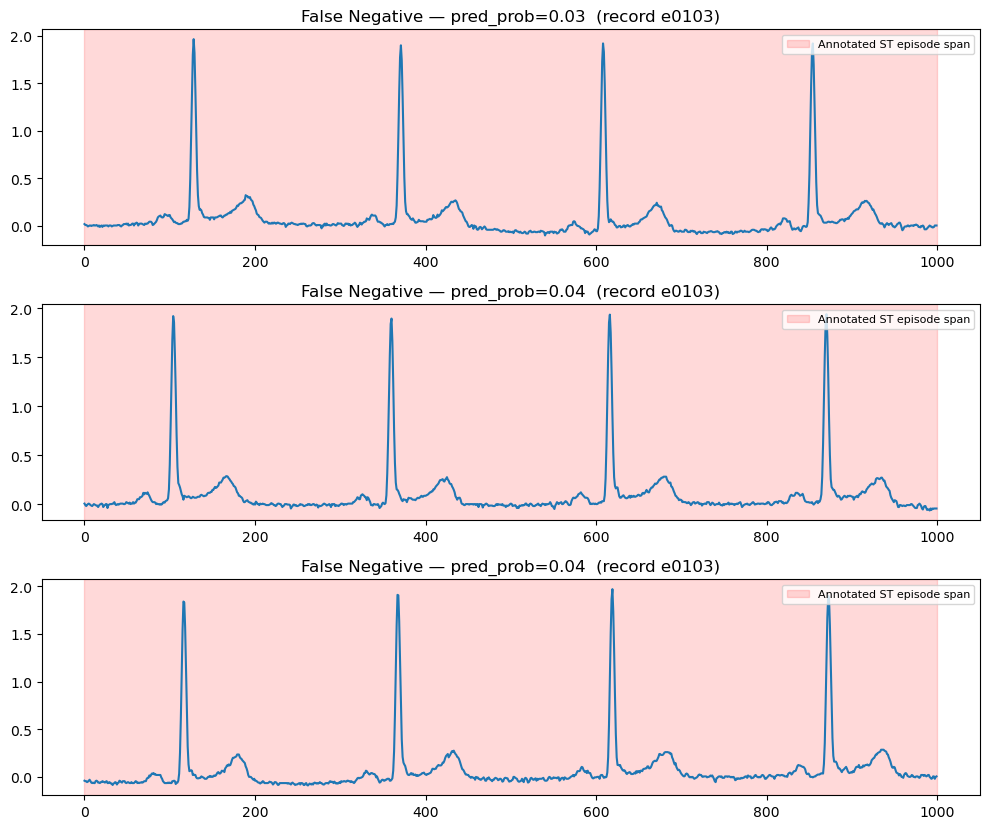

In [27]:
## Overlay ST episode onset/peak/offset markers on false-negative windows

def extract_positive_windows_with_meta(record_name, episodes_for_record, pn_dir='edb', lead_idx=0):
    sig = None
    for attempt in range(3):
        try:
            sig, fields = wfdb.rdsamp(record_name, pn_dir=pn_dir)
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2)
            else:
                raise

    signal = sig[:, lead_idx]
    baseline = np.median(signal)
    signal = signal - baseline

    meta_windows = []
    for ep in episodes_for_record:
        onset, offset = ep['onset'], ep['offset']
        peak = ep.get('peak', None)
        span = offset - onset
        if span < WINDOW_SIZE:
            continue
        n_win = max(1, span // WINDOW_SIZE)
        for i in range(n_win):
            start = onset + i * WINDOW_SIZE
            end = start + WINDOW_SIZE
            if end <= offset:
                meta_windows.append({
                    'signal': signal[start:end],
                    'record': record_name,
                    'win_start': start,
                    'onset': onset,
                    'peak': peak,
                    'offset': offset,
                })
    return meta_windows

# Rebuild positive windows with metadata for every test record
test_pos_meta = []
for rec in test_records:
    eps = [e for e in all_episodes if e['record'] == rec]
    if not eps:
        continue
    test_pos_meta.extend(extract_positive_windows_with_meta(rec, eps))

# Match each false-negative test window to its metadata by exact signal match
def find_meta_for_window(window, meta_list):
    w = window.flatten()
    for m in meta_list:
        if np.array_equal(w, m['signal']):
            return m
    return None

fig, axes = plt.subplots(len(fn_idx[:3]), 1, figsize=(10, 2.8 * len(fn_idx[:3])))
if len(fn_idx[:3]) == 1:
    axes = [axes]

for i, idx in enumerate(fn_idx[:3]):
    window = X_test_r[idx].flatten()
    meta = find_meta_for_window(window, test_pos_meta)

    axes[i].plot(window)
    title = f"False Negative — pred_prob={y_pred_prob_t[idx]:.2f}"

    if meta is not None:
        onset_x = meta['onset'] - meta['win_start']
        offset_x = meta['offset'] - meta['win_start']
        axes[i].axvspan(max(onset_x, 0), min(offset_x, len(window)), color='red', alpha=0.15, label='Annotated ST episode span')
        if meta['peak'] is not None:
            peak_x = meta['peak'] - meta['win_start']
            if 0 <= peak_x <= len(window):
                axes[i].axvline(peak_x, color='darkred', linestyle='--', linewidth=1, label='Annotated peak')
        title += f"  (record {meta['record']})"
        axes[i].legend(fontsize=8, loc='upper right')
    else:
        title += "  (metadata match not found)"

    axes[i].set_title(title)

plt.tight_layout()
plt.show()

False negatives span 17 distinct records
{'e0103': 183, 'e0107': 217, 'e0114': 195, 'e0116': 113, 'e0147': 184, 'e0148': 142, 'e0204': 80, 'e0210': 373, 'e0212': 129, 'e0406': 92, 'e0410': 32, 'e0415': 235, 'e0501': 38, 'e0604': 468, 'e0613': 234, 'e0615': 5, 'e0808': 57}


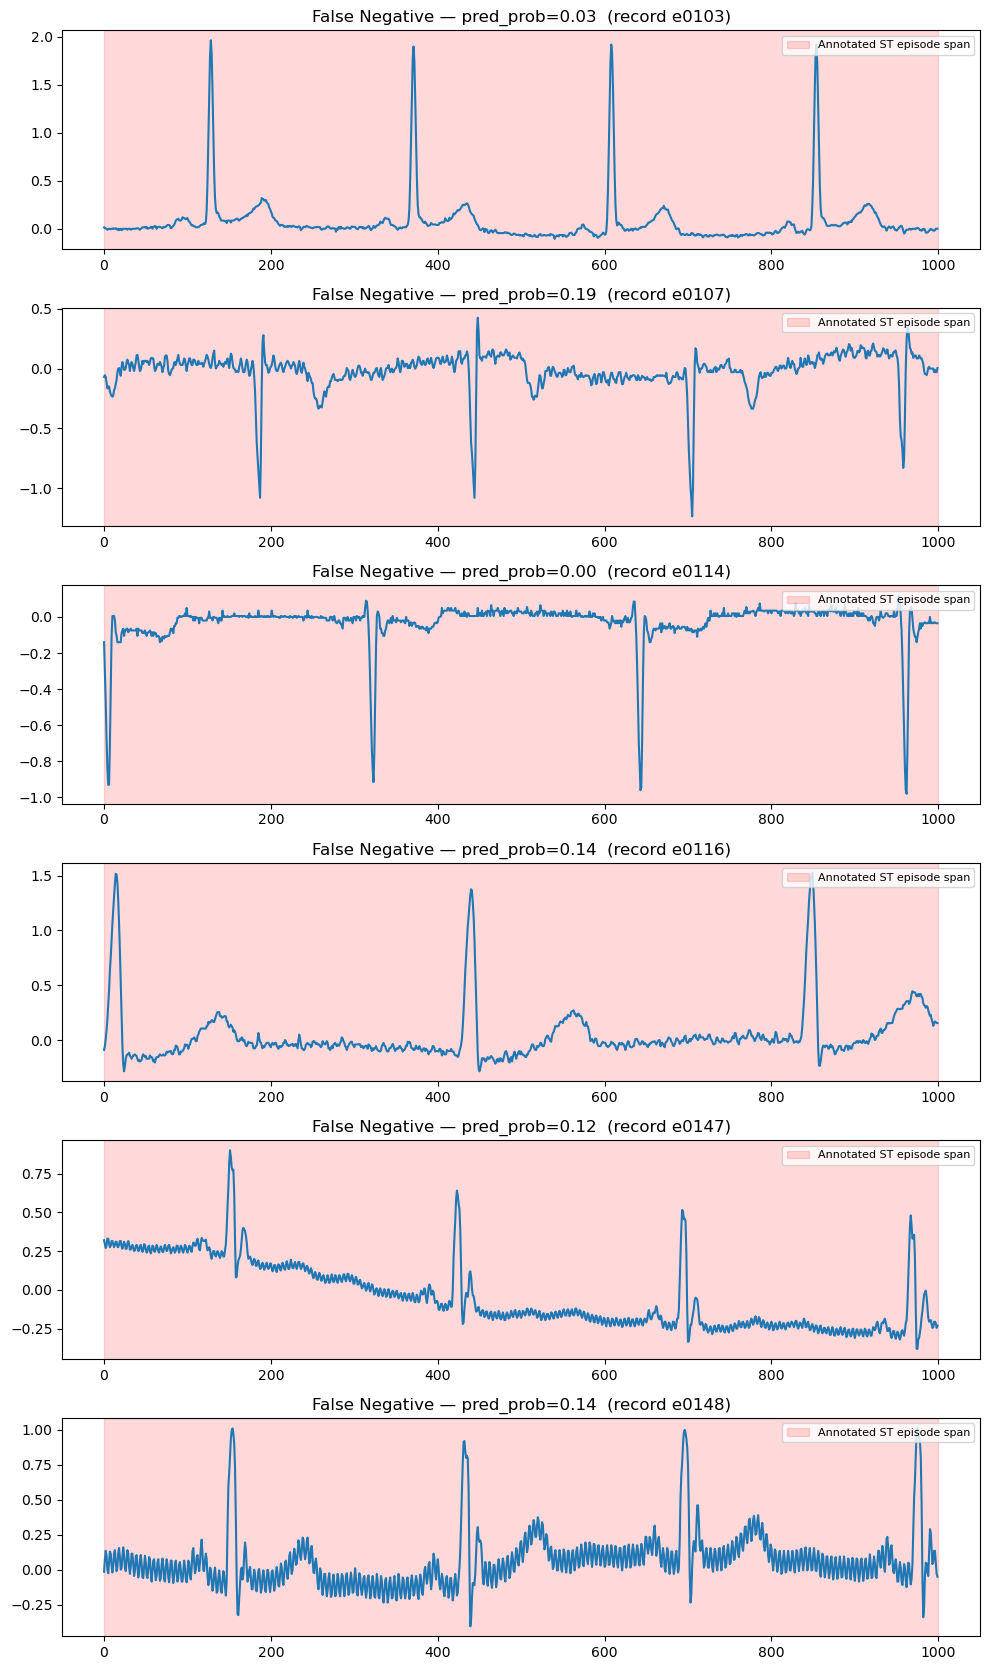

In [28]:
## Overlay ST episode markers on a broader, multi-record sample of false negatives

# Build a record->fn_idx lookup so we can sample across different records
fn_by_record = {}
for idx in fn_idx:
    meta = find_meta_for_window(X_test_r[idx].flatten(), test_pos_meta)
    rec = meta['record'] if meta is not None else 'unknown'
    fn_by_record.setdefault(rec, []).append(idx)

print(f"False negatives span {len(fn_by_record)} distinct records")
print({rec: len(idxs) for rec, idxs in fn_by_record.items()})

# Pick one example from each of up to 6 different records
sample_records_fn = list(fn_by_record.keys())[:6]
sample_idx = [fn_by_record[rec][0] for rec in sample_records_fn]

fig, axes = plt.subplots(len(sample_idx), 1, figsize=(10, 2.8 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = [axes]

for i, idx in enumerate(sample_idx):
    window = X_test_r[idx].flatten()
    meta = find_meta_for_window(window, test_pos_meta)

    axes[i].plot(window)
    title = f"False Negative — pred_prob={y_pred_prob_t[idx]:.2f}"

    if meta is not None:
        onset_x = meta['onset'] - meta['win_start']
        offset_x = meta['offset'] - meta['win_start']
        axes[i].axvspan(max(onset_x, 0), min(offset_x, len(window)), color='red', alpha=0.15, label='Annotated ST episode span')
        if meta['peak'] is not None:
            peak_x = meta['peak'] - meta['win_start']
            if 0 <= peak_x <= len(window):
                axes[i].axvline(peak_x, color='darkred', linestyle='--', linewidth=1, label='Annotated peak')
        title += f"  (record {meta['record']})"
        axes[i].legend(fontsize=8, loc='upper right')
    else:
        title += "  (metadata match not found)"

    axes[i].set_title(title)

plt.tight_layout()
plt.show()